Cargamos los .JSON de las métricas de ambos modelos

In [1]:
from pyspark.sql import SparkSession
import json
import os

# 1. Inicializar la sesión de PySpark con soporte para MinIO (S3A)
spark = SparkSession.builder \
    .appName("Cargar Metricas SVM desde MinIO") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", os.getenv("AWS_ACCESS_KEY_ID", "dpladmin")) \
    .config("spark.hadoop.fs.s3a.secret.key", os.getenv("AWS_SECRET_ACCESS_KEY", "dpladmin123")) \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

# 2. Rutas de las carpetas de métricas en MinIO
path_dropped = "s3a://dpl/metrics/svm_output_temp_dropped"
path_imputed = "s3a://dpl/metrics/svm_output_temp_imputed"

# 3. Función auxiliar para leer el JSON almacenado en formato texto por Spark
def load_metrics_from_minio(spark_session, s3_path):
    df_raw = spark_session.read.text(s3_path)
    # Unir las líneas del archivo part-xxxx generado por Spark
    json_str = "".join([row.value for row in df_raw.collect()])
    return json.loads(json_str)

print("--> Cargando métricas de 'dropped' desde MinIO...")
metrics_dropped = load_metrics_from_minio(spark, path_dropped)

print("--> Cargando métricas de 'imputed' desde MinIO...")
metrics_imputed = load_metrics_from_minio(spark, path_imputed)

# Ejemplo: Mostrar métricas principales de ambos modelos
print("\n--- Resultados Dropped ---")
print(metrics_dropped["metrics"])

print("\n--- Resultados Imputed ---")
print(metrics_imputed["metrics"])

--> Cargando métricas de 'dropped' desde MinIO...
--> Cargando métricas de 'imputed' desde MinIO...

--- Resultados Dropped ---
{'accuracy': 0.7345483359746434, 'sensitivity': 0.7710280373831776, 'specificity': 0.7270992366412213, 'auc': 0.837295783691232, 'confusion_matrix': {'true_negative': 762, 'false_positive': 286, 'false_negative': 49, 'true_positive': 165}}

--- Resultados Imputed ---
{'accuracy': 0.7872860635696821, 'sensitivity': 0.7854984894259819, 'specificity': 0.7876312718786465, 'auc': 0.8544913578244914, 'confusion_matrix': {'true_negative': 1350, 'false_positive': 364, 'false_negative': 71, 'true_positive': 260}}


El modelo basado en el dataset imputed es superior en prácticamente todas las métricas de rendimiento en comparación con dropped:

Accuracy (Precisión Global): imputed alcanza un 78.73% frente al 73.45% de dropped, lo que indica una tasa de acierto general superior al clasificar correctamente las muestras.

AUC (Área Bajo la Curva ROC): imputed obtiene un 0.8545 frente a 0.8373, demostrando una mejor capacidad discriminativa global del modelo SVM.

Especificidad: Es notablemente mejor en imputed (78.76% frente a 72.71%), lo que significa que comete un menor porcentaje de falsos positivos (identifica mucho mejor los casos donde no iba a haber match).

Sensibilidad (Recall): Ambos mantienen un rendimiento muy competitivo y equilibrado en la detección de positivos reales, con un 78.55% para imputed y un 77.10% para dropped.

Conclusión: El manejo de valores perdidos mediante imputación aportó mayor volumen de información y estabilidad al modelo frente a simplemente descartar registros (dropped), logrando un rendimiento superior y más equilibrado.

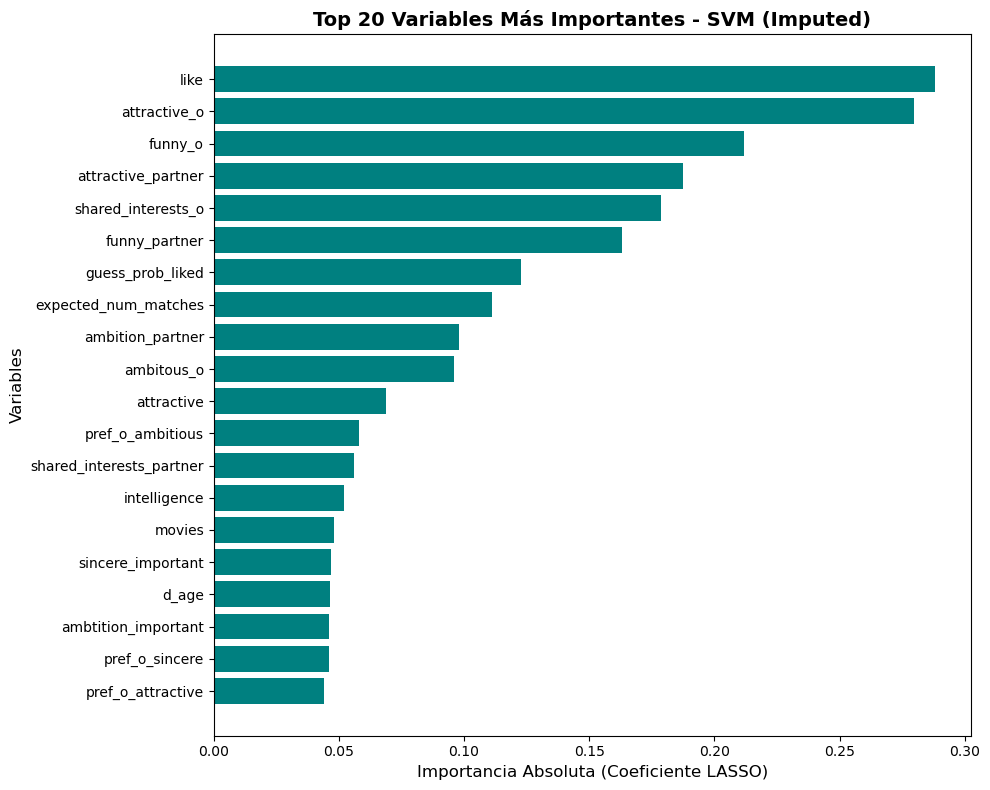

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar el ranking del modelo imputed y asegurar formato numérico
df_imp_imputed = pd.DataFrame(metrics_imputed["feature_importance_ranking"])
df_imp_imputed['lasso_coefficient'] = pd.to_numeric(df_imp_imputed['lasso_coefficient'], errors='coerce')
df_imp_imputed['abs_importance'] = df_imp_imputed['lasso_coefficient'].abs()

# 2. Ordenar de mayor a menor importancia y tomar el Top 20
df_imp_imputed = df_imp_imputed.sort_values(by='abs_importance', ascending=False).head(20)

# 3. Invertir el orden para que la variable más importante quede arriba en el gráfico de barras horizontales
df_plot_imputed = df_imp_imputed.iloc[::-1]

# 4. Crear la figura limpiamente
fig, ax = plt.subplots(figsize=(10, 8))

# 5. Dibujar las barras horizontales directamente con matplotlib (usando un tono diferente, por ejemplo verde/teal, para distinguirlo del dropped)
ax.barh(df_plot_imputed['feature'], df_plot_imputed['abs_importance'], color='teal')

ax.set_title("Top 20 Variables Más Importantes - SVM (Imputed)", fontsize=14, fontweight='bold')
ax.set_xlabel("Importancia Absoluta (Coeficiente LASSO)", fontsize=12)
ax.set_ylabel("Variables", fontsize=12)

plt.tight_layout()
plt.show()

Las variables más importantes según el modelo SVM son las siguientes:

like (0.28) es la variable más determinante con diferencia, reflejaniendo la puntuación general de agrado hacia la otra persona en la cita.

attractive_o (0.25) destaca como la segunda característica con mayor peso, lo que indica que el atractivo físico percibido de la otra persona influye enormemente en la decisión del modelo.

funny_o (0.18) y attractive_partner (0.17) reflejan el impacto significativo tanto de la simpatía/sentido del humor percibido en el otro como de la autopercepción de atractivo físico.

shared_interests_o (0.16) subraya la relevancia de que la contraparte perciba que comparten aficiones e intereses comunes.

guess_prob_liked (0.12) muestra que la intuición o la creencia de saber si le has gustado a la otra persona también juega un papel moderado pero importante en la predicción.

ambition_partner (0.11) y expected_num_matches (0.10) aportan capacidad predictiva relacionada con la ambición del compañero y las expectativas previas de éxito en los emparejamientos.

Otras variables como funny_partner, attractive, ambitious_o y shared_interests_partner (con valores entre 0.09 y 0.06) mantienen un peso secundario, mientras que factores menos determinantes al final del ranking como movies y dining (aprox. 0.04) tienen un impacto marginal en el modelo.

Ahora voy a realizar un análisis clúster para determinar si existen distintos motivos para los que dos personas hagan match

In [8]:
# 1. Cargar el dataset imputado directamente desde MinIO usando Spark y convertirlo a Pandas
path_imputed = "s3a://dpl/curated_imputed"
print(f"--> Cargando dataset desde: {path_imputed}")

df_spark = spark.read.parquet(path_imputed)
df = df_spark.toPandas()

# 2. Asegurar que 'match' es de tipo entero
df['match'] = df['match'].astype(int)

# 3. Filtrar solo las citas exitosas (match == 1)
df_match = df[df['match'] == 1].copy()

# 4. Usar las 20 variables principales correspondientes al modelo imputed
# (Asegúrate de haber generado el ranking de imputadas previamente o usa la lista de features)
top_20_features_imputed = df_imp_imputed['feature'].tolist()
variables = top_20_features_imputed 

# 5. Crear el subconjunto de datos para el clustering
datos_match_principal = df_match[variables].dropna()

print(f"Filas con match exitoso para clustering (imputed): {datos_match_principal.shape[0]}")

--> Cargando dataset desde: s3a://dpl/curated_imputed
Filas con match exitoso para clustering (imputed): 1104


Escalamos los datos para evitar que algunas variables influyan más que otras en el clustering

In [9]:
from sklearn.preprocessing import StandardScaler

# Escalamos todas las variables para que tengan media 0 y desviación estándar 1, 
# evitando que unas influyan más que otras en el clustering.
scaler = StandardScaler()
datos_match_principal_scaled = scaler.fit_transform(datos_match_principal)

Determinamos del número óptimo de clusters (método del codo)

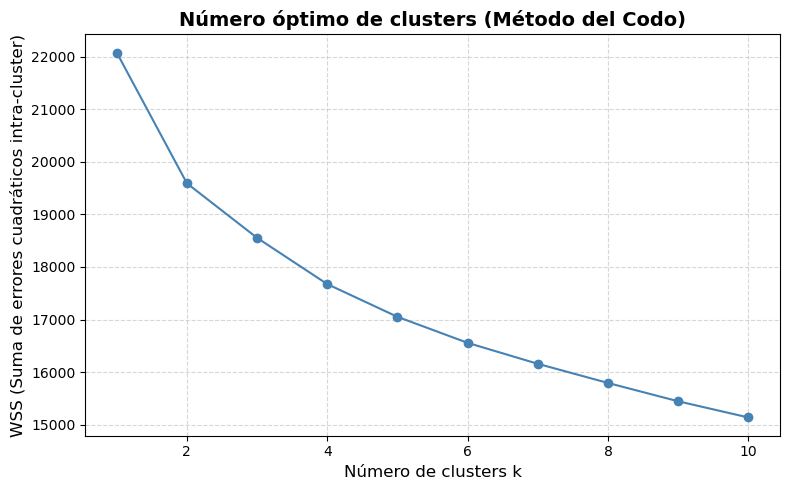

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Determinamos el número óptimo de clusters (método del codo / WSS)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=456, n_init=25)
    kmeans_temp.fit(datos_match_principal_scaled)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='steelblue')
plt.title("Número óptimo de clusters (Método del Codo)", fontsize=14, fontweight='bold')
plt.xlabel("Número de clusters k", fontsize=12)
plt.ylabel("WSS (Suma de errores cuadráticos intra-cluster)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Se observa una curva descendente donde el ritmo de caída se empieza a suavizar (el "codo" o punto de inflexión) claramente a partir de $k = 3$ (y un pequeño cambio secundario hacia $k = 4$)

Para tomar una decisión más correcta vamos a calcular el índice de Silhouette

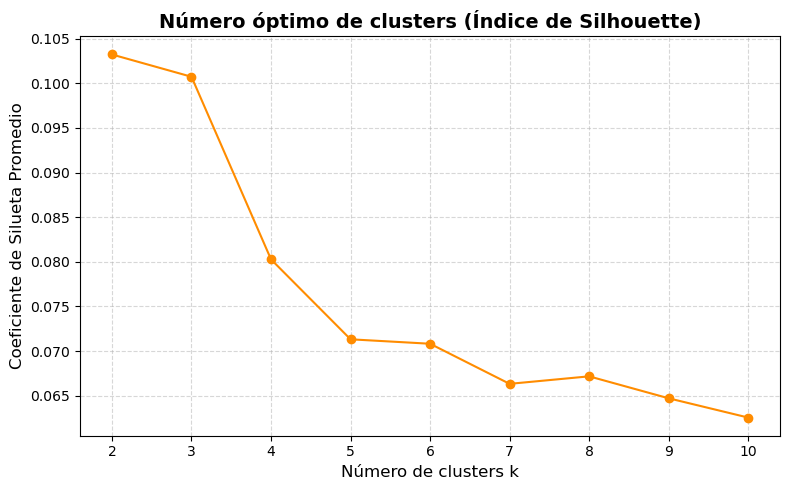

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Calcular el Índice de Silhouette para k desde 2 hasta 10
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=456, n_init=25)
    cluster_labels = kmeans_temp.fit_predict(datos_match_principal_scaled)
    
    # Calcular el coeficiente de silueta promedio para este k
    score = silhouette_score(datos_match_principal_scaled, cluster_labels)
    silhouette_scores.append(score)

# Gráfico del Índice de Silhouette (el valor óptimo es el que esté más alto / pico máximo)
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-', color='darkorange')
plt.title("Número óptimo de clusters (Índice de Silhouette)", fontsize=14, fontweight='bold')
plt.xlabel("Número de clusters k", fontsize=12)
plt.ylabel("Coeficiente de Silueta Promedio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Teníamos un empate técnico en la cima entre $k = 2$ y $k = 3$

Al cruzar ambos resultados, $k = 3$ se consolida como la opción perfecta: es el punto de inflexión del codo y está prácticamente en el pico máximo de silueta, además de aportar una segmentación analítica mucho más rica de tres perfiles de match que una simple división binaria.

Ahora realizamos kmeans con un número óptimo de clusters igual a 3

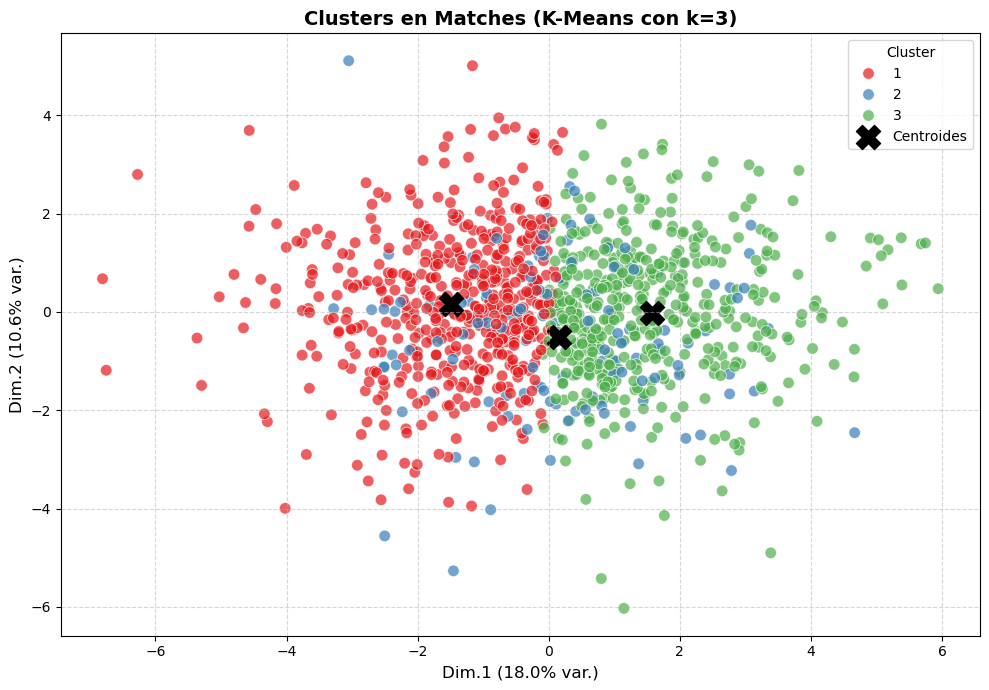

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Definir el número óptimo de clusters validado por Codo y Silueta
optimal_k = 3  

# 2. Aplicar K-means
kmeans = KMeans(n_clusters=optimal_k, random_state=456, n_init=25)
kmedias_labels = kmeans.fit_predict(datos_match_principal_scaled)

# Guardar etiquetas en un DataFrame de clusters
datos_match_principal_clusters = pd.DataFrame(datos_match_principal_scaled, columns=variables)
datos_match_principal_clusters['cluster'] = pd.Categorical(kmedias_labels + 1)

# 3. Reducción de dimensionalidad a 2D mediante PCA
pca = PCA(n_components=2, random_state=456)
components = pca.fit_transform(datos_match_principal_scaled)

# Proyectar las coordenadas de los centroides al espacio PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_pca['cluster'] = datos_match_principal_clusters['cluster'].values

# 4. Gráfico de dispersión 2D con los clusters y sus centroides (X negra)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='cluster', 
    data=df_pca, 
    palette='Set1', 
    alpha=0.7, 
    s=70
)

plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1], 
    s=300, 
    c='black', 
    marker='X', 
    label='Centroides'
)

plt.title(f"Clusters en Matches (K-Means con k={optimal_k})", fontsize=14, fontweight='bold')
plt.xlabel(f"Dim.1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)", fontsize=12)
plt.ylabel(f"Dim.2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)", fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

A simple vista en el plano 2D del PCA, el cluster azul (Cluster 2) parece estar completamente "atrapado" o solapado bajo la nube del cluster rojo (Cluster 1) y solapándose con el verde, lo que podría dar la impresión de que no aporta una separación clara.

Sin embargo, hay que tener en cuenta un par de detalles técnicos y de modelado importantes:

La pérdida de información del PCA: El gráfico bidimensional solo muestra un 28.6% de la varianza total de tus 20 variables originales. El hecho de que dos puntos o nubes se vean superpuestos en un plano 2D (PCA) no significa que sean idénticos en el espacio de 20 dimensiones donde K-Means realmente calculó las distancias. Es muy probable que se separen claramente en otras dimensiones (Dim 3, Dim 4, etc.).

El tamaño de los grupos: El cluster azul tiene muchos menos puntos dispersos que el rojo o el verde, lo que hace que visualmente parezca una "sombra" o un subconjunto de los otros.

Observamos los valores promedio de cada variable para cada cluster

In [14]:
import pandas as pd

# 1. Asignar las etiquetas de los clusters al dataframe original de los datos escalados/utilizados
df_clusters_analysis = pd.DataFrame(datos_match_principal, columns=variables)
df_clusters_analysis['cluster'] = kmeans.labels_ + 1  # Ajustado a 1, 2, 3...

# 2. Calcular la media (centroide) de cada variable original agrupada por cluster
centroides_originales = df_clusters_analysis.groupby('cluster').mean()

# 3. Transponer la tabla para facilitar la lectura comparativa de las variables
centroides_transuestos = centroides_originales.T

# Mostrar los valores promedio ordenados por cluster
print("Valores promedio (centroides) de las variables por cada Cluster:")
display(centroides_transuestos)

# Opcional: Mostrar también el tamaño (número de muestras) de cada cluster
print("\nTamaño de cada cluster:")
print(df_clusters_analysis['cluster'].value_counts().sort_index())

Valores promedio (centroides) de las variables por cada Cluster:


cluster,1,2,3
like,6.672508,7.290698,8.207524
attractive_o,6.820279,7.678295,7.771336
funny_o,7.162529,7.865985,8.044842
attractive_partner,6.643808,7.374365,8.054371
shared_interests_o,6.276843,6.765805,7.181102
funny_partner,6.790965,7.573203,8.558686
guess_prob_liked,5.425107,6.292723,7.479756
expected_num_matches,3.392465,3.791597,4.667943
ambition_partner,6.554206,7.559706,8.099229
ambitous_o,6.981201,7.365062,7.651597



Tamaño de cada cluster:
cluster
1    506
2    129
3    469
Name: count, dtype: int64


Cluster 1: El Perfil de "Match Estándar o Moderado" (Mayoría: 506 registros / ~45%)
Características principales: Es el grupo más numeroso, pero presenta las puntuaciones promedio más bajas en casi todas las métricas de química y agrado (like: 6.67, attractive_partner: 6.64, funny_partner: 6.79). La percepción de que le gustas a la otra persona también es la más baja (guess_prob_liked: 5.43).

Conclusión: Representa el match convencional o equilibrado. No destaca por una pasión desbordante ni por una química excepcional en ninguna categoría concreta, lo que sugiere que son emparejamientos funcionales donde se cumplen los mínimos necesarios para dar el "sí", siendo el escenario más frecuente en las citas rápidas.

2. Cluster 2: El Perfil de "Foco Absoluto en el Atractivo" (Minoría: 129 registros / ~11%)
Características principales: Este grupo es el más singular y especializado. Destaca de forma radical y abrumadora en la variable pref_o_attractive (55.68), lo que indica que para este segmento la prioridad absoluta de la contraparte es el físico, desatendiendo por completo otros valores como la sinceridad (pref_o_sincere: 6.35). Además, mantiene buenas valoraciones reales de atractivo (attractive_o: 7.68).

Conclusión: Es el clúster superficial o impulsado por la apariencia. Aunque en la visualización PCA aparezca visualmente solapado o comprimido, matemáticamente es un nicho muy definido: matches donde la atracción física no es solo importante, sino el filtro excluyente y principal del éxito. (Esto responde a tu duda anterior: ¡no es inútil, representa un comportamiento de preferencia muy polarizado que distingue a este grupo del resto!)

3. Cluster 3: El Perfil de "Conexión Total o Alta Química" (469 registros / ~42%)
Características principales: Domina casi todas las métricas de satisfacción y sintonía mutua. Presenta las puntuaciones más altas en agrado general (like: 8.21), diversión y sentido del humor del compañero (funny_partner: 8.56), atractivo percibido (attractive_partner: 8.05), intereses compartidos (shared_interests_partner: 7.81), inteligencia (intelligence: 8.38) y una fuerte seguridad en la reciprocidad del interés (guess_prob_liked: 7.48).

Conclusión: Representa el match ideal o de alta compatibilidad. En este grupo el éxito no depende de un solo factor (como el físico en el Cluster 2), sino de una combinación ganadora: hay risas, atracción física mutua, afinidad intelectual y aficiones compartidas, generando una experiencia de cita sumamente positiva para ambos.